# Strategy Comparison — Momentum vs Mean-Reversion vs Random Baseline


Runs `MomentumStrategy`, `MeanReversionStrategy`, and `RandomBaseline` against one shared
GBM price path through one exchange, each with its own isolated `Portfolio` under a single
`PortfolioManager`. Compares them with the new `analytics/` layer: per-strategy
`PerformanceReport` (Sharpe, max drawdown, Calmar, win rate) via `analytics.compare()`, and
return correlation across strategies via `analytics.correlation_matrix()`.

This is a single seeded price path, not a distribution over many — Monte Carlo re-runs (N=1000
seeded draws) are Phase 3, not built yet. Treat every number below as one draw, not as the
strategies' expected performance.

In [ ]:
import matplotlib.pyplot as plt

from market_sim.analytics import compare, correlation_matrix
from market_sim.core.config import default_config
from market_sim.core.engine.runtime_engine import RuntimeEngine
from market_sim.core.models import EventType, OrderType, Side
from market_sim.exchange import build_exchange
from market_sim.exchange.orderbook import Order
from market_sim.market.generators import PriceGenerator
from market_sim.portfolio import PortfolioManager
from market_sim.strategies import MeanReversionStrategy, MomentumStrategy, RandomBaseline

## Build the simulation

Strategies always submit `MARKET` orders (per `ARCHITECTURE.md`), which need a resting
counterparty to fill against. Nothing in `src/` provides organic two-sided liquidity yet (no
market-maker/liquidity-provider component exists — that's a real gap, not an oversight), so
this notebook seeds one directly: a `MARKET_UPDATE` handler that rests a large two-sided quote
around the current price every tick, inserted straight into the `OrderBook` the same way unit
test fixtures do. This is notebook glue for a research demo, not new production code.

In [2]:
config = default_config()  # GBM: mu=0.05, sigma=0.20, n_steps=252, dt=1/252, seed=42

runtime = RuntimeEngine()
book, trade_log, gateway = build_exchange(runtime)

price_events = PriceGenerator(config, runtime.clock).generate()
for event in price_events:
    runtime.queue.push(event)


def make_liquidity_provider(book, spread_bps=20.0, quantity=1_000_000.0):
    counter = iter(range(10**9))

    def handler(event):
        price = event.data["price"]
        offset = price * spread_bps / 10_000
        book.insert(Order(
            order_id=f"lp-bid-{next(counter)}", side=Side.BUY, order_type=OrderType.LIMIT,
            price=price - offset, quantity=quantity, timestamp=event.timestamp,
        ))
        book.insert(Order(
            order_id=f"lp-ask-{next(counter)}", side=Side.SELL, order_type=OrderType.LIMIT,
            price=price + offset, quantity=quantity, timestamp=event.timestamp,
        ))

    return handler


runtime.loop.register_handler(EventType.MARKET_UPDATE, make_liquidity_provider(book))

In [3]:
strategies = [
    MomentumStrategy(
        strategy_id="momentum", initial_cash=100_000.0, clock=runtime.clock,
        order_id_factory=runtime.next_order_id, lookback=5, trade_size=10.0,
    ),
    MeanReversionStrategy(
        strategy_id="mean_reversion", initial_cash=100_000.0, clock=runtime.clock,
        order_id_factory=runtime.next_order_id, lookback=10, threshold=1.0, trade_size=10.0,
    ),
    RandomBaseline(
        strategy_id="random", initial_cash=100_000.0, clock=runtime.clock,
        order_id_factory=runtime.next_order_id, trade_size=10.0, seed=7,
    ),
]

manager = PortfolioManager()
portfolios = {
    strategy.strategy_id: manager.register_strategy(strategy.strategy_id, initial_cash=100_000.0)
    for strategy in strategies
}


def make_market_update_handler(strategy, portfolio):
    def handler(event):
        for order_event in strategy.on_market_update(event):
            runtime.queue.push(order_event)
            portfolio.track_order(order_event.data["order_id"])
    return handler


for strategy in strategies:
    portfolio = portfolios[strategy.strategy_id]
    runtime.loop.register_handler(
        EventType.MARKET_UPDATE, make_market_update_handler(strategy, portfolio)
    )
    runtime.loop.register_handler(EventType.TRADE_EXECUTION, strategy.on_fill)

runtime.loop.register_handler(EventType.MARKET_UPDATE, manager.on_market_update)
runtime.loop.register_handler(EventType.TRADE_EXECUTION, manager.on_fill)

In [4]:
runtime.start()

print(f"ticks processed: {len(price_events)}")
print(f"trades executed: {trade_log.trade_count()}")
print(f"orders rejected: {len(gateway.rejected_orders)}")

ticks processed: 252
trades executed: 567
orders rejected: 0


## Performance comparison

`periods_per_year = 1 / config.dt` annualizes Sharpe/Calmar correctly for this config's step
size (252 steps/year here) rather than assuming a hardcoded 252 — `SimConfig.dt` is
configurable, so the analytics layer takes this as an explicit argument (see
`analytics/metrics/metrics.py`).

In [5]:
report = compare(manager, periods_per_year=1 / config.dt)
report

,equity,realized_pnl,unrealized_pnl,sharpe,max_drawdown,calmar,win_rate
strategy_id,,,,,,,
momentum,118272.416381,18272.416381,0.000000,0.648813,0.024838,3.568443,1.0
mean_reversion,111735.939181,8680.719385,3055.219797,0.613966,0.032150,2.312150,1.0
random,112594.628481,12507.493556,87.134925,0.632573,0.022054,3.248752,1.0


## Return correlation across strategies

All three strategies react to the *same* underlying price path, so some correlation is expected
even between economically unrelated signals — this isn't evidence they're "the same trade,"
just that they all key off one shared GBM series.

In [6]:
corr = correlation_matrix(manager.equity_curves())
corr

,momentum,mean_reversion,random
momentum,1.000000,-0.066020,-0.005602
mean_reversion,-0.066020,1.000000,0.056107
random,-0.005602,0.056107,1.000000


## Equity curves

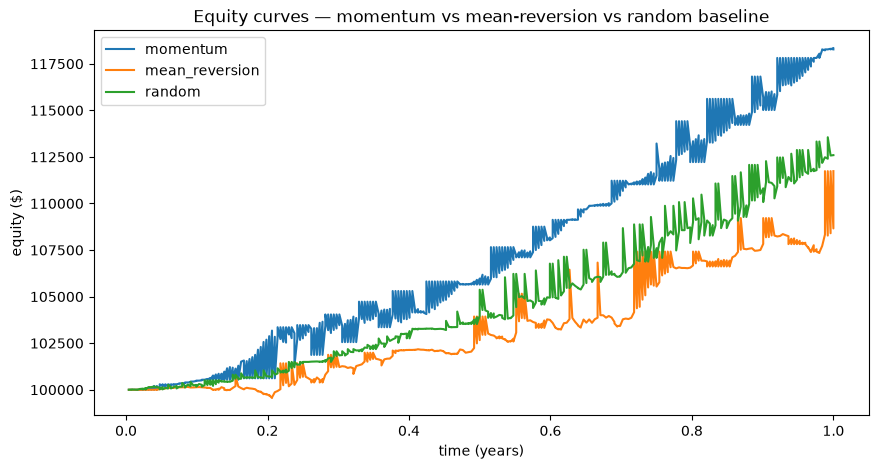

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
for strategy_id, curve in manager.equity_curves().items():
    timestamps, equity = zip(*curve)
    ax.plot(timestamps, equity, label=strategy_id)
ax.set_xlabel("time (years)")
ax.set_ylabel("equity ($)")
ax.set_title("Equity curves — momentum vs mean-reversion vs random baseline")
ax.legend()
plt.show()